# ML LAB 2

# NAME: SHEERAZ AHMED, CMS:023-24-0171, SEC:F

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mosapabdelghany/telcom-customer-churn-dataset")

Using Colab cache for faster access to the 'telcom-customer-churn-dataset' dataset.


In [ ]:
import pandas as pd
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
print(df.columns)
print(df.dtypes)

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object



# Part 1

**Task1**

The telecom company is losing customers to other companies so we need to predict who will leave early to stop them
The target variable is the Churn column

**Task 2**

**5 predictors**

 Contract: Month to month users can cancel easily compared to 1 or 2 year contracts
 tenure: Brand new customers leave faster than old ones
 MonthlyCharges: High bills push people to find cheaper options
 TechSupport: Users without help get frustrated with issues and leave
 InternetService: The connection type might have bad speed causing people to leave


**2 useless columns**

 customerID It is just a random ID and does not help predict anything


 gender Being male or female does not change if someone stays with a telecom company


**Task 3**

**My personal questions**

 Do customers with high bills and month to month contracts leave the most
 Do senior citizens stay just because they do not want the trouble of switching

**Part 2**

In [ ]:
import pandas as pd
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df['Contract'].unique())
print(df['PaymentMethod'].unique())
print(df['gender'].unique())

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
['Mont

**Task 4**

There are 7043 customers and 21 features in this dataset

Numerical columns:

SeniorCitizen
tenure
MonthlyCharges

Categorical columns:

gender
Partner
Dependents
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
Churn

**Task 5**

customerID is purely an identifier and not a predictive feature


TotalCharges shows as an object string but it represents billed money so it needs to be changed to a numerical float type

**Task 6**

Contract: Month to month, One year, Two year
PaymentMethod: Electronic check, Mailed check, Bank transfer, Credit card
gender: Female Male

# Part 3

In [ ]:
missing_values=df.isnull().sum()
missing_percent=(df.isnull().mean()*100)
duplicates=df.duplicated().sum()
id_duplicates=df['customerID'].duplicated().sum()
print(missing_values)
print(missing_percent)
print(duplicates)
print(id_duplicates)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64
0
0


**Task 7**

shows 0 missing values and 0 percent missing across all columns

**Task 8**

There are 0 completely duplicated rows and 0 duplicated customer IDs
These are different issues because duplicate rows mean the exact same data was entered twice while duplicate IDs mean the same customer might have two different records

**Task 9**

The TotalCharges column is suspicious because it has a string data type but it should be a numeric type
I found this by checking the dataset structure in the previous part
The missing values are likely hidden as empty text spaces instead of standard empty values which is why the missing value count showed 0

# Part 4

**Task 10**

Problem: TotalCharges column has empty string spaces hiding 11 missing values and has the wrong data type

Decision: Change the data type to numeric to expose the missing values and then remove those 11 rows

Method: Using pd to numeric with errors coerce and df dropna

Reason: TotalCharges represents billed money so it must be numeric and dropping just 11 rows out of 7043 is safe and will not harm the dataset

**Task 11**

In [ ]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
clean_df=df.dropna()
print(clean_df.isnull().sum())
print(clean_df.shape)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
(7032, 21)


# Part 5

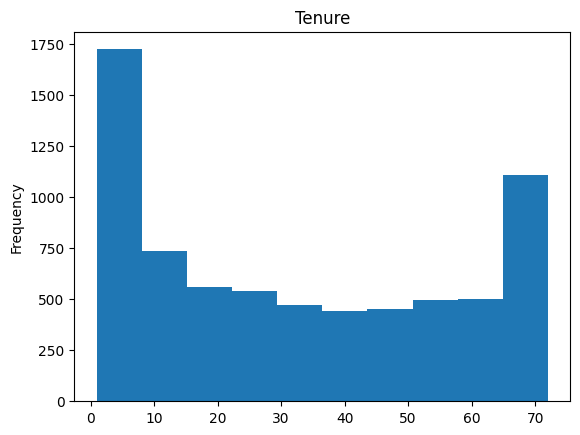

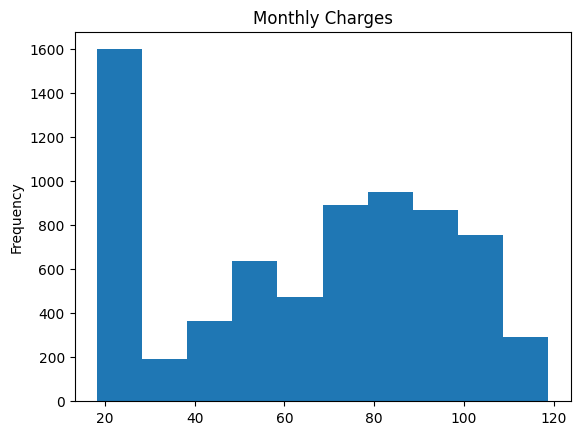

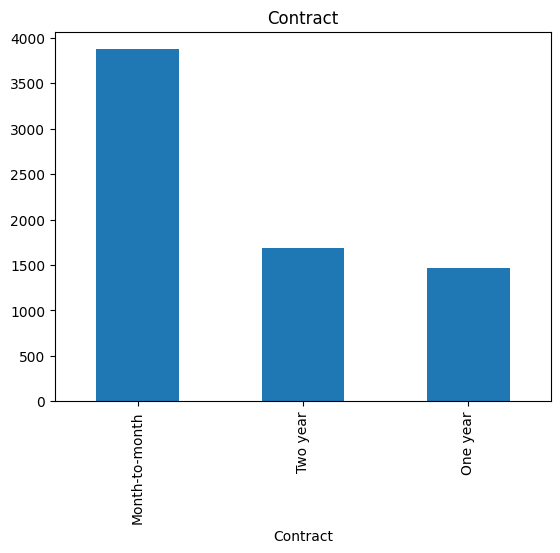

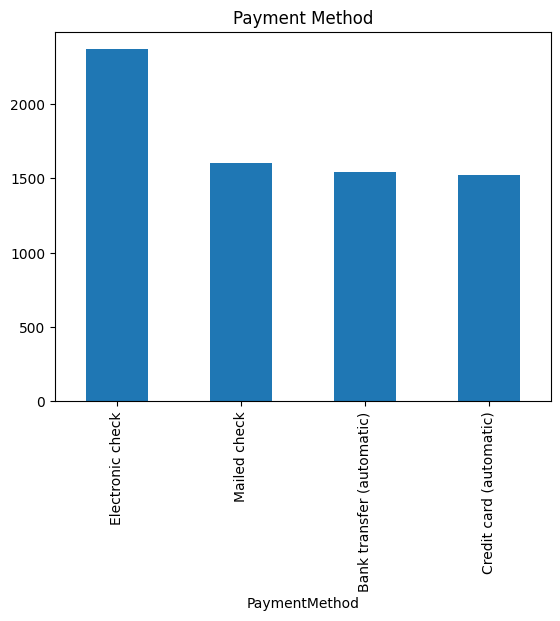

In [17]:
import matplotlib.pyplot as plt
clean_df['tenure'].plot(kind='hist')
plt.title('Tenure')
plt.show()
clean_df['MonthlyCharges'].plot(kind='hist')
plt.title('Monthly Charges')
plt.show()
clean_df['Contract'].value_counts().plot(kind='bar')
plt.title('Contract')
plt.show()
clean_df['PaymentMethod'].value_counts().plot(kind='bar')
plt.title('Payment Method')
plt.show()

**Task 12**

Tenure:

The chart has a U shape showing most customers are either brand new or have stayed with the company for over 60 months

Monthly Charges:

A huge number of customers pay a very low bill around 20 creating a massive spike on the left
There is another large group paying between 70 and 100

Contract:

Most customers use month to month contracts making it the most popular choice
Two year and one year contracts are much less common

Payment Method:

Electronic check is the most popular way people pay their bills
The other three methods are used almost exactly the same amount

**Task 13**

The MonthlyCharges distribution is skewed because there is a giant spike on the far left side
This might happen because the company offers a very cheap basic plan that most people buy without adding extra expensive services

# Part 6

In [18]:
print(clean_df['Churn'].value_counts())
print(clean_df['Churn'].value_counts(normalize=True)*100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


**Task 14**

Number of customers:

Non churned customers who stayed are 5163
Churned customers who left are 1869

Percentage of customers:

Non churned percentage is roughly 73 percent
Churned percentage is roughly 27 percent

The target variable is very imbalanced because the number of customers who stayed is much larger than the number of customers who left

**Task 15**

If the dataset has way more people who stay the model will just learn to predict that everyone stays
It can get a very high accuracy score by completely ignoring the people who leave but that makes it useless for the company
We need the model to actually find the rare customers who churn so the imbalance will cause huge problems when training

# Part 7

**Task 16**

In [19]:
print(pd.crosstab(clean_df['Contract'],clean_df['Churn'],normalize='index'))
print(pd.crosstab(clean_df['InternetService'],clean_df['Churn'],normalize='index'))

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887228  0.112772
Two year        0.971513  0.028487
Churn                  No       Yes
InternetService                    
DSL              0.810017  0.189983
Fiber optic      0.581072  0.418928
No               0.925658  0.074342


Feature 1 Contract:
Observation Month to month customers leave way more than others
Evidence The output shows about 43 percent of month to month customers leave compared to just 11 percent for one year and 3 percent for two year contracts
Possible Explanation People on month to month can leave anytime without penalty fees so they switch easily to other companies

Feature 2 InternetService:
Observation Fiber optic users have the highest chance of leaving
Evidence The output shows almost 42 percent of fiber optic users leave compared to only 19 percent for DSL users and 7 percent for those with no internet
Possible Explanation The fiber optic service might be too expensive or it might have bad speed and drop connection often making people angry

**Task 17**

In [21]:
print(clean_df.groupby('Churn')[['tenure','MonthlyCharges']].mean())

          tenure  MonthlyCharges
Churn                           
No     37.650010       61.307408
Yes    17.979133       74.441332


Feature 1 tenure:
Observation Customers who leave usually have a very short tenure
Evidence The output shows people who leave have an average tenure of about 18 months while people who stay have an average of about 37 months
Possible Explanation Brand new customers have not built loyalty yet so they leave easily if they find a better deal

Feature 2 MonthlyCharges:
Observation Customers who leave usually pay higher monthly bills
Evidence The output shows people who leave pay about 74 per month on average while people who stay pay only about 61
Possible Explanation High expensive bills force people to look for cheaper options from competitors

# Part 8

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.246862      0.825880
MonthlyCharges  0.246862        1.000000      0.651065
TotalCharges    0.825880        0.651065      1.000000


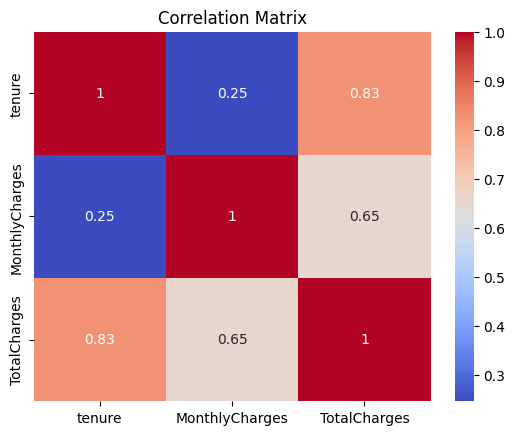

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = clean_df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
print(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Task 18**

The heatmap perfectly confirms the strong positive correlation between TotalCharges and tenure(0.83)

It also highlights the secondary strong correlation between TotalCharges and MonthlyCharges (0.65)

The weak correlation between tenure and MonthlyCharges (0.25) is accurately represented by the darker blue squares

**Task 19**

TotalCharges is mathematically derived from the other two variables rather than being a separate behavioral cause

To prevent this heavy overlap from confusing a future classification model and artificially skewing feature importance the best practice is to drop the TotalCharges column before moving into the machine learning phase

# Part 9

**Task 20**

**customerID:** This is the primary suspect because it is purely an identifier It is simply a unique string assigned to each account and holds no behavioral or demographic value that could actually predict why someone leaves

**Churn (Target Variable):** the target variable itself must be separated from the input features before training otherwise the model already has the answer

**Task 21**

If a pure identifier is left in the machine learning model might just memorize the specific IDs of people who churned instead of learning the underlying patterns which causes severe overfitting If a true data leakage column were left in the model would essentially be cheating by looking at the answer key It would look artificially perfect during testing but would fail completely in the real world because that future data would not exist at the moment you need to make a prediction

# Part 10

**Task 22**

| Column | Type | Role | Action | Reason |
| --- | --- | --- | --- | --- |
| customerID | Identifier | — | Remove | add no predictive value and risks overfitting |
| gender | Categorical | Feature | Encode | must be converted to numeric for ML |
| SeniorCitizen | Numerical | Feature | Keep | Already encoded as 0/1: ready for ML |
| Partner | Categorical | Feature | Encode | must be converted to numeric for ML |
| Dependents | Categorical | Feature | Encode | must be converted to numeric for ML |
| tenure | Numerical | Feature | Keep | ready for ML |
| PhoneService | Categorical | Feature | Encode | must be converted to numeric for ML |
| MultipleLines | Categorical | Feature | Encode | Service feature; must be converted to numeric for ML |
| InternetService | Categorical | Feature | Encode | Strong predictor (Fiber optic); must be converted to numeric |
| OnlineSecurity | Categorical | Feature | Encode | must be converted to numeric for ML |
| OnlineBackup | Categorical | Feature | Encode | must be converted to numeric for ML |
| DeviceProtection | Categorical | Feature | Encode | must be converted to numeric for ML |
| TechSupport | Categorical | Feature | Encode | must be converted to numeric for ML |
| StreamingTV | Categorical | Feature | Encode | must be converted to numeric for ML |
| StreamingMovies | Categorical | Feature | Encode | must be converted to numeric for ML |
| Contract | Categorical | Feature | Encode | must be converted to numeric |
| PaperlessBilling | Categorical | Feature | Encode | must be converted to numeric for ML |
| PaymentMethod | Categorical | Feature | Encode | must be converted to numeric for ML |
| MonthlyCharges | Numerical | Feature | Keep | ready for ML |
| TotalCharges | Numerical | Feature | Remove | High multicollinearity with tenure and MonthlyCharges |
| Churn | Categorical | Target | Encode / Keep | Target variable: must be mapped to 1/0 for model training |

# Part 11

**Task 23**

In [28]:
clean_df = clean_df.drop(columns=['customerID', 'TotalCharges'], errors='ignore')

clean_df = clean_df.drop_duplicates()

clean_df.to_csv('clean_churn.csv', index=False)

**Task 24**

In [29]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7005 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7005 non-null   object 
 1   SeniorCitizen     7005 non-null   int64  
 2   Partner           7005 non-null   object 
 3   Dependents        7005 non-null   object 
 4   tenure            7005 non-null   int64  
 5   PhoneService      7005 non-null   object 
 6   MultipleLines     7005 non-null   object 
 7   InternetService   7005 non-null   object 
 8   OnlineSecurity    7005 non-null   object 
 9   OnlineBackup      7005 non-null   object 
 10  DeviceProtection  7005 non-null   object 
 11  TechSupport       7005 non-null   object 
 12  StreamingTV       7005 non-null   object 
 13  StreamingMovies   7005 non-null   object 
 14  Contract          7005 non-null   object 
 15  PaperlessBilling  7005 non-null   object 
 16  PaymentMethod     7005 non-null   object 
 17  

# Part 12

**Task 25**

**finding one**

observation: people on month to month plans leave way more

evidence: data shows about 43 percent of them churn while one year and two year plans are much lower

interpretation: they can leave anytime without paying a fee so they switch easily

**finding two**

observation: fiber optic users leave the most

evidence: about 42 percent of them cancel which is way higher than dsl

interpretation maybe it costs too much or drops connection often making people mad

**finding three**

observation: brand new customers leave fast

evidence: people who leave stay for about 18 months while others stay for 37 months

interpretation: the company has a bad onboarding process so new people get unhappy and quit

**finding four**

observation: people with big monthly bills leave more

evidence: churned users pay around 74 dollars a month while others pay 61 dollars

interpretation: expensive bills make people search for cheaper options

**finding five**

observation: most people stay and few leave

evidence: about 73 percent stay and 27 percent leave

interpretation: models will get lazy and just predict everyone stays so we need special tricks

**Task 26**

most important data quality issue: finding hidden missing spaces in total charges that looked like text instead of numbers

most interesting pattern: the weird mix of fiber optic users leaving even though it is a premium service

most useful feature: contract type and how long they stayed

feature not to use: customer id because it is just a random tag and total charges because it repeats monthly bills and tenure

preprocessing: we need to change text into numbers scale values and fix the heavy data imbalance

what next if three hours left: check combinations of monthly bills and fiber optic plans or build new ratio features